# Choose Your Own Hypothesis Project:

### An Analysis on the Impact of NATO Membership on Semiconductor Imports

For my final project I decided to examine how NATO membership relates to the amount, in U.S. Dollar, countries import seminconductors. I became interested in learning about semiconductor trade after listening to a podcast on how the industry works. I found it fascinating how it is the backbone of most of todays innovations and yet it is hardly discussed outside of technical circles. Because of its importance to innovation and the technology supply chain, semiconductors are viewed as essential imports to many nations and therefore important for national security. It was this tie to national security that made me curious if NATO countries, which is the largest defensive alliance, have started working towards importing more semiconductors.

Now that I have established what I want to examine I will put my hypothesis in statistical terms:

**Null Hypothesis (H₀):** NATO membership makes no difference in mean semiconductor import value. Any observed difference is completely due to chance

**Alternative Hypothesis (H₁):** NATO countries import a higher amount of semiconductors, in terms of the value in USD of these semiconductors, as compared to Non-NATO countries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats
import random
import seaborn as sns

---
### Data Loading/Preperation
To begin to try and awnser the question of how NATO membership might semiconductor imports I had to to get the following two data sets:

'semi_conductor_imports_2024.csv' contains data country level data of the import value, in USD, of semi conductors in the year 2024
'Nato_Member_States.csv' is the list of current NATO members

Since their was no single source that contained both semiconductor import values and NATO membership data I had to get two seperate data sets and join them 

In [36]:
semiconductors = pd.read_csv('semi_conductor_imports_2024.csv')
nato_states = pd.read_csv('Nato_Member_States.csv')

Now that both datasets are loaded, I began by normalizing the case of the countries names to make joining them easier.

In [37]:
semiconductors['Country'] = semiconductors['Country'].str.lower()
nato_states['Country'] = nato_states['Country'].str.lower()

Next, I created a set of all of the countries that are in NATO.

In [38]:
nato = set(nato_states["Country"])

Since the data is now in a set, I added a binary boolean field to the semiconductor dataframe (1 == NATO : 0 == Non-Nato) based on the common country field.

In [39]:
semiconductors["In Nato"] = semiconductors["Country"].isin(nato).astype(int)

Next, I verified that the number of countries in my NATO set mapped matched the number of countries designated in the semiconductor dataframe. I was concerned that if their were any variations in spelling/formatting of the names that the join would miss some countries.

In [40]:
print(semiconductors["In Nato"].value_counts())
print(len(nato))

In Nato
0    190
1     32
Name: count, dtype: int64
32


I then just wanted to quickly view the new combined dataframe to ensure everything looks as it should which it did.

In [41]:
semiconductors

,Continent,Continent ID,Country,Country ID,ISO 3,Trade Value,Year,In Nato
0,Africa,af,algeria,afdza,dza,4.242791e+07,2024,0
1,Africa,af,egypt,afegy,egy,2.006779e+08,2024,0
2,Africa,af,libya,aflby,lby,1.811450e+06,2024,0
3,Africa,af,morocco,afmar,mar,1.303057e+09,2024,0
4,Africa,af,sudan,afsdn,sdn,8.348756e+06,2024,0
...,...,...,...,...,...,...,...,...
217,South America,sa,paraguay,sapry,pry,3.674413e+06,2024,0
218,South America,sa,suriname,sasur,sur,6.517640e+05,2024,0
219,South America,sa,uruguay,saury,ury,4.127947e+06,2024,0
220,South America,sa,venezuela,saven,ven,2.717164e+06,2024,0


---
### EDA

Now that my data has been loaded I started by creating some initial visualizations to get an idea of some general trends in the data.

First I created a overlayed density plot, this allowed me to examine what each groups general imports looked like. This inital plot gave me two important insights. First, while the majority of the data is in the same general vacinity, there are some quite large trade values within both groups. Secondly, I was initialy confused why the Non-Nato States density around 0 was so large but then I realized that most countires just dont import that many semi conductors. Its also important to note that of the 222 countires only 32 are NATO members so there is just significantly more data about Non-NATO states.

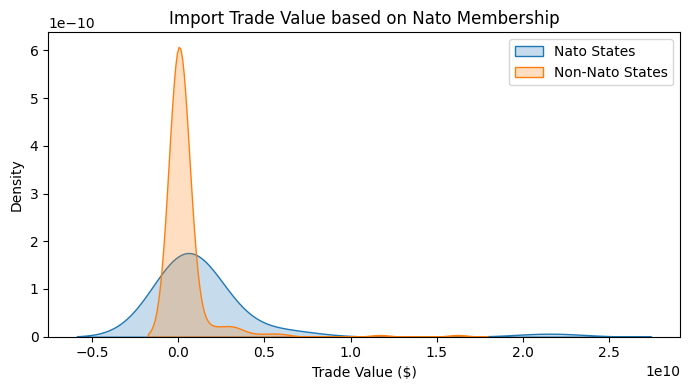

In [42]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.kdeplot(semiconductors[semiconductors['In Nato'] == 1]['Trade Value'], fill=True, ax=ax, label='Nato States')
sns.kdeplot(semiconductors[semiconductors['In Nato'] == 0]['Trade Value'], fill=True, ax=ax, label='Non-Nato States')
ax.set_xlabel('Trade Value ($)')
ax.set_ylabel('Density')
ax.set_title('Import Trade Value based on Nato Membership')
ax.legend()
plt.tight_layout()
plt.show()

Next, I created boxplots to see if I could confirm the existence of some outliers. Not only did this plot confirm the existance of some outliers but, it also made me realize that the outliers could be extreme outliers based on how squished the boxplots are in comparison to the outlier points.

/var/folders/7r/wcgjm2ts2kqd5xg4nc1w_rg00000gn/T/ipykernel_50883/4155622813.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


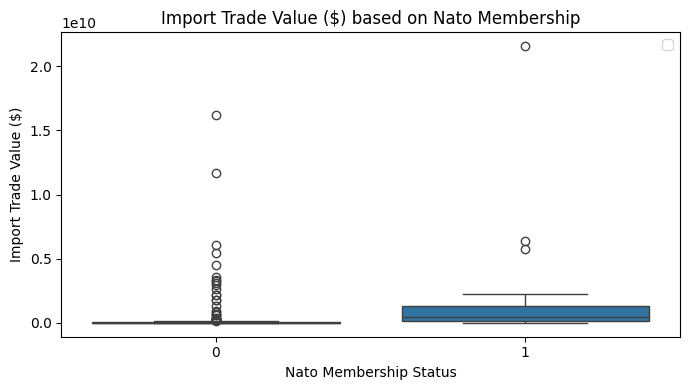

In [43]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=semiconductors, x='In Nato', y='Trade Value', ax=ax)
ax.set_xlabel('Nato Membership Status')
ax.set_ylabel('Import Trade Value ($)')
ax.set_title('Import Trade Value ($) based on Nato Membership')
ax.legend()
plt.tight_layout()
plt.show()

Given the shape of the density plot and the bloxplots, I began to suspect my data was heavily skewed. To test a possible work around I decided to create a new coloumn that is the Lof of Trade Value. This is one way we can possible account for the skew in my analysis.

In [44]:
semiconductors['Log Trade Value'] = np.log10(semiconductors['Trade Value'])

I then recreated my boxplot comparison plot and this resulted in a much more "normal" looking box plot that allowed my to start to get an idea of how I might compare NATO and Non-NATO states.

/var/folders/7r/wcgjm2ts2kqd5xg4nc1w_rg00000gn/T/ipykernel_50883/2202603639.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


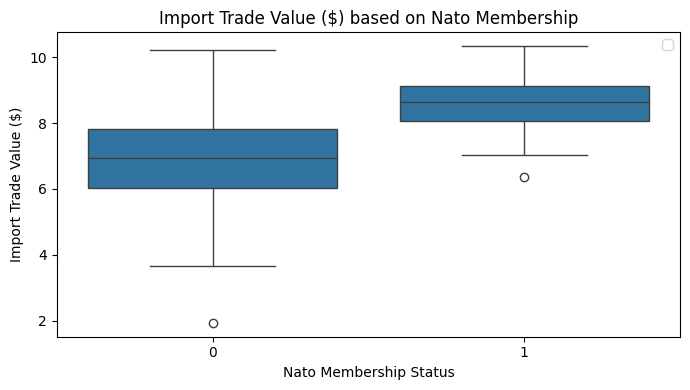

In [45]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=semiconductors, x='In Nato', y='Log Trade Value', ax=ax)
ax.set_xlabel('Nato Membership Status')
ax.set_ylabel('Import Trade Value ($)')
ax.set_title('Import Trade Value ($) based on Nato Membership')
ax.legend()
plt.tight_layout()
plt.show()

To confirm my suspicion that the data is skewed, and that taking the Log of the Trade Values might help in my analysis, I created two histograms. I created one with the Raw Trade Values and that used Log Trade Values. This confirmed that my data was right skewed. The Log Trade Value also appeared to by close to normally distibuted.

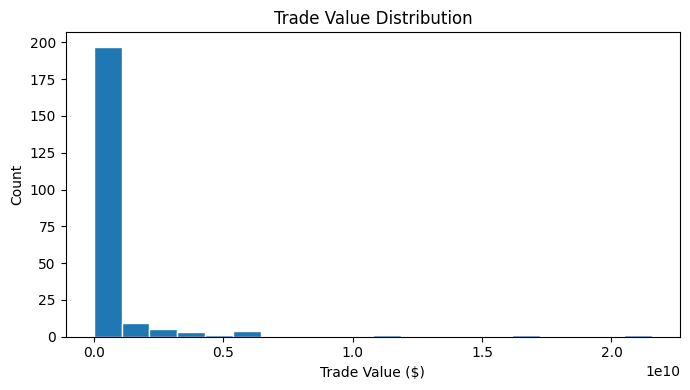

In [46]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(semiconductors['Trade Value'], bins=20, edgecolor='white')
ax.set_xlabel('Trade Value ($)')
ax.set_ylabel('Count')
ax.set_title('Trade Value Distribution')
plt.tight_layout()
plt.show()

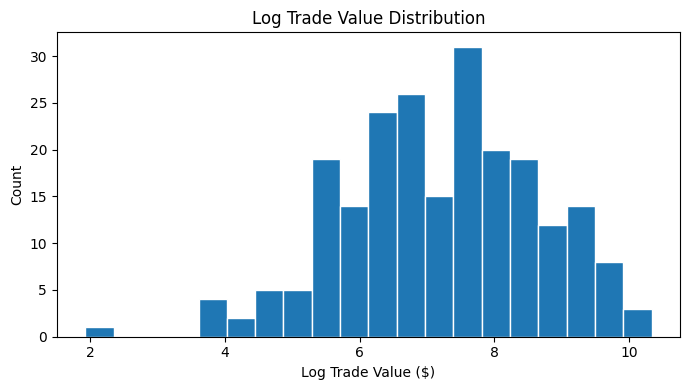

In [47]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.log10(semiconductors['Trade Value']), bins=20, edgecolor='white')
ax.set_xlabel('Log Trade Value ($)')
ax.set_ylabel('Count')
ax.set_title('Log Trade Value Distribution')
plt.tight_layout()
plt.show()

---
### Permutation Testing

For my permutation test, I decided to use calculated the mean difference in Trade Value between NATO and Non-NATO countries. I created two seperate methods calculate this, one for raw trade values and one for the log values. I then calculated the observed differences based on the original data.

The observed mean difference for the raw trade value was: 1186950187.699 |
The observed mean difference for the log trade value was: 1.641

In [48]:
def nato_diff(df):
    means = df.groupby('In Nato')['Trade Value'].mean()
    return means[1] - means[0]

In [49]:
def nato_diff_log(df):
    means = df.groupby('In Nato')['Log Trade Value'].mean()
    return means[1] - means[0]

In [50]:
observed_value = nato_diff(semiconductors)
print(f"Observed difference: {observed_value:.3f}")

observed_log_value = nato_diff_log(semiconductors)
print(f"Observed log difference: {observed_log_value:.3f}")

Observed difference: 1186950187.699
Observed log difference: 1.641


Because of the skew in the data, I decided to do permutation tests based on both the raw trade value and the log trade values.

In [51]:
replicates = [observed_value]
replicates_log = [observed_log_value]
num_sim = 10000
for_simulation = semiconductors.copy()
nato_col = for_simulation['In Nato'].tolist()

for _ in range(num_sim -1):
    np.random.shuffle(nato_col)
    for_simulation['In Nato'] = nato_col
    replicates.append(nato_diff(for_simulation))
    replicates_log.append(nato_diff_log(for_simulation))

replicates = pd.DataFrame({'replicates': replicates})
replicates_log = pd.DataFrame({'replicates': replicates_log})

### Raw Trade Value Permutation Test Analysis

Firstly, its important to note that the permutation test on the raw trade value continues the trend of a right skew found in the initial data. Based on an examination of the dataset I belive China is one of the main culprits of this skew. As by far the largest importer of semiconductors their impact on the mean is significant. That being said. the original difference of $1,186,950,187.70 is statistically significant as the observed p-value was 0.0114. So if we take 0.05 at the cutoff, we would reject the null hypothesis.

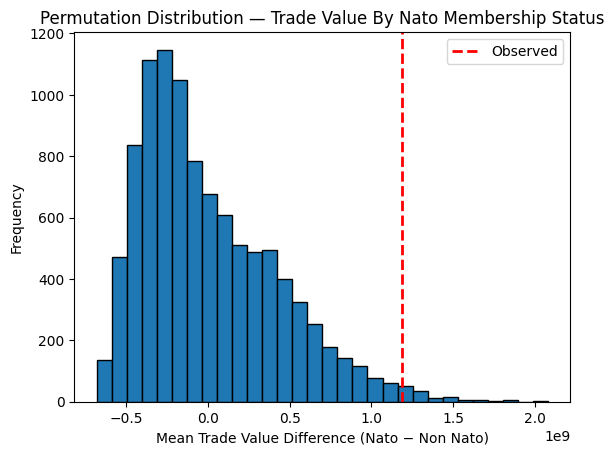

In [52]:
plt.hist(replicates['replicates'], bins=30, edgecolor='black')
plt.axvline(observed_value, color='red', linestyle='--', linewidth=2, label='Observed')
plt.xlabel('Mean Trade Value Difference (Nato − Non Nato)')
plt.ylabel('Frequency')
plt.title('Permutation Distribution — Trade Value By Nato Membership Status')
plt.legend()
plt.show()

In [53]:
np.mean(replicates['replicates'] >= observed_value)

np.float64(0.0114)

### Log Trade Value Permutation Test Analysis

This permutiation is normally distributed, as the shape of the distribution is normal and is centered around a difference of 0. We can then process with a more traditional analysis of the observed difference in log trade value.

If we once again take 0.05 as the cutoff, we would still reject the null hypothesis as our difference of 1.641 has a p-value of 0.0001.

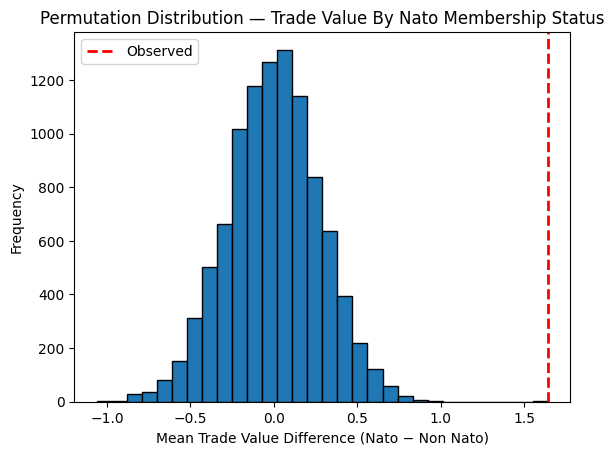

In [54]:
plt.hist(replicates_log['replicates'], bins=30, edgecolor='black')
plt.axvline(observed_log_value, color='red', linestyle='--', linewidth=2, label='Observed')
plt.xlabel('Mean Trade Value Difference (Nato − Non Nato)')
plt.ylabel('Frequency')
plt.title('Permutation Distribution — Trade Value By Nato Membership Status')
plt.legend()
plt.show()

In [55]:
np.mean(replicates_log['replicates'] >= observed_log_value)

np.float64(0.0001)

Both of our permutation tests had p-values below 0.05 meaning both rejected the null hypothesis that the difference in mean trade value of imported semiconductors between NATO and Non-NATO countires occured due to chance.

---
### Bootstrapping

Since I ran permutation tests on both the raw trade value and the log trade value I decided to do the samething in my bootstrap. I also decided to try bootstrapping the median as well to see what the differences look like between raw and log trade values and because in this case the Central Limit Theorem (CLT) would not apply to the median.

For the actual bootstrapping I ran each simulation 1000 times.

In [56]:
boot_data = semiconductors.groupby('In Nato')['Trade Value'].mean().reset_index()
boot_log_data = semiconductors.groupby('In Nato')['Log Trade Value'].mean().reset_index()

In [57]:
nato_copy = semiconductors[['In Nato', 'Trade Value']]

boot_data['boot_mean'] = pd.NA
boot_data['boot_median'] = pd.NA
boot_data['boot_se'] = pd.NA
boot_data['boot_median_se'] = pd.NA

num_sim = 1000

for idx, row in boot_data.iterrows() :
    this_nato = row['In Nato']
    this_gp = nato_copy.query(f"`In Nato` == {this_nato}")

    mean_samples = []
    median_samples = []

    for _ in range (num_sim) : 
        this_sample = this_gp.sample(n=len(this_gp), replace=True)
        mean_samples.append(np.mean(this_sample['Trade Value']))
        median_samples.append(np.median(this_sample['Trade Value']))

    boot_data.loc[boot_data['In Nato'] == this_nato, 'boot_mean'] = np.mean(mean_samples)
    boot_data.loc[boot_data['In Nato'] == this_nato, 'boot_median'] = np.mean(median_samples)
    boot_data.loc[boot_data['In Nato'] == this_nato, 'boot_se'] = np.std(mean_samples)
    boot_data.loc[boot_data['In Nato'] == this_nato, 'boot_median_se'] = np.std(median_samples)

boot_data

,In Nato,Trade Value,boot_mean,boot_median,boot_se,boot_median_se
0,0,4.325062e+08,435088194.940179,8832578.096,121546428.430583,2635574.857352
1,1,1.619456e+09,1627975410.586625,489535141.483,702087833.80185,225236218.762831


There are a couple of important things that should be noted about the bootstrap on the raw trade values.

1) This shows us that the bootstrapped mean & median trade values for NATO countries are significantly higher than the Non-NATO countriess.
2) There is no overlap in the standard errors in either mesurment between groups which is important especially since the se on both measrements for the NATO group is quite large. This would mean to me that this is most likely a meaningful difference.

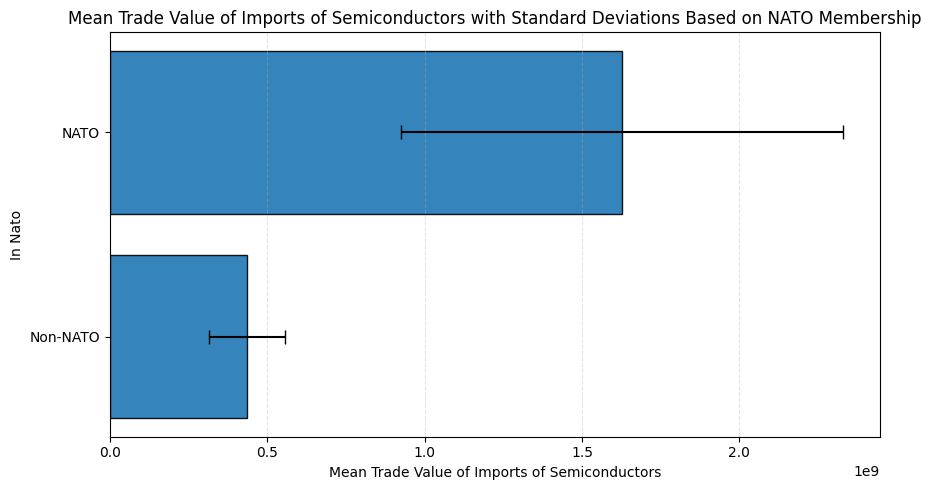

In [58]:
plot_data = boot_data[['In Nato', 'boot_mean', 'boot_se']].copy()
plot_data['boot_se'] = pd.to_numeric(plot_data['boot_se'])
plot_data = plot_data.sort_values('boot_mean')
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    y=plot_data['In Nato'],
    width=plot_data['boot_mean'],
    xerr=plot_data['boot_se'],
    edgecolor='black',
    alpha=0.9,
    capsize=5,
)
ax.set_xlabel('Mean Trade Value of Imports of Semiconductors')
ax.set_ylabel('In Nato')
ax.set_title('Mean Trade Value of Imports of Semiconductors with Standard Deviations Based on NATO Membership')
ax.grid(axis='x', linestyle='--', alpha=0.35)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Non-NATO', 'NATO'])
plt.tight_layout()
plt.show()

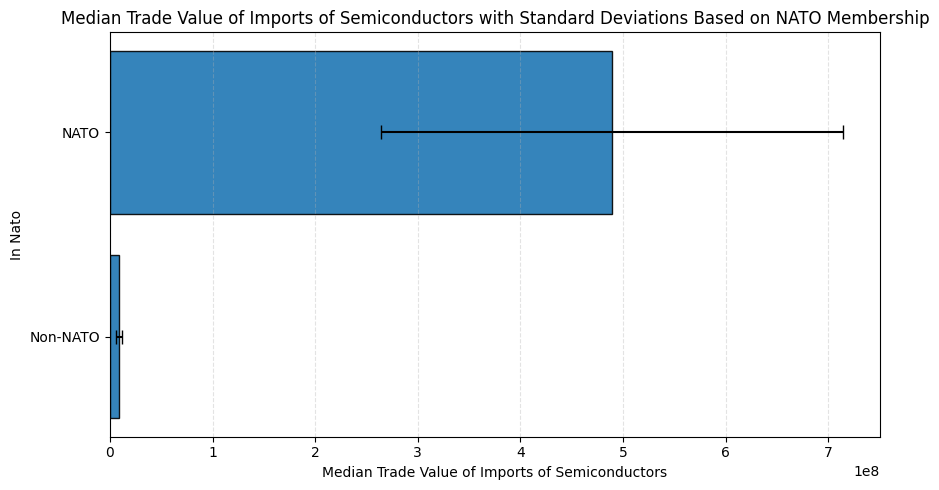

In [59]:
plot_data = boot_data[['In Nato', 'boot_median', 'boot_median_se']].copy()
plot_data['boot_median_se'] = pd.to_numeric(plot_data['boot_median_se'])
plot_data = plot_data.sort_values('boot_median')
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    y=plot_data['In Nato'],
    width=plot_data['boot_median'],
    xerr=plot_data['boot_median_se'],
    edgecolor='black',
    alpha=0.9,
    capsize=5,
)
ax.set_xlabel('Median Trade Value of Imports of Semiconductors')
ax.set_ylabel('In Nato')
ax.set_title('Median Trade Value of Imports of Semiconductors with Standard Deviations Based on NATO Membership')
ax.grid(axis='x', linestyle='--', alpha=0.35)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Non-NATO', 'NATO'])
plt.tight_layout()
plt.show()

In [60]:
nato_log_copy = semiconductors[['In Nato', 'Log Trade Value']]

boot_log_data['boot_mean'] = pd.NA
boot_log_data['boot_median'] = pd.NA
boot_log_data['boot_se'] = pd.NA
boot_log_data['boot_median_se'] = pd.NA

num_sim = 1000

for idx, row in boot_log_data.iterrows() :
    this_nato = row['In Nato']
    this_gp = nato_log_copy.query(f"`In Nato` == {this_nato}")

    mean_samples = []
    median_samples = []

    for _ in range (num_sim) : 
        this_sample = this_gp.sample(n=len(this_gp), replace=True)
        mean_samples.append(np.mean(this_sample['Log Trade Value']))
        median_samples.append(np.median(this_sample['Log Trade Value']))

    boot_log_data.loc[boot_log_data['In Nato'] == this_nato, 'boot_mean'] = np.mean(mean_samples)
    boot_log_data.loc[boot_log_data['In Nato'] == this_nato, 'boot_median'] = np.mean(median_samples)
    boot_log_data.loc[boot_log_data['In Nato'] == this_nato, 'boot_se'] = np.std(mean_samples)
    boot_log_data.loc[boot_log_data['In Nato'] == this_nato, 'boot_median_se'] = np.std(median_samples)

boot_log_data

,In Nato,Log Trade Value,boot_mean,boot_median,boot_se,boot_median_se
0,0,6.952503,6.953292,6.932901,0.104487,0.11433
1,1,8.593281,8.589311,8.636374,0.144478,0.200514


There are a couple of important things that should be noted about the bootstrap on the log trade values.

1) This shows us that the bootstrapped mean & median log trade values for NATO countries are still different on this scale even though viusally the bars are closer in length.
2) There is still no overlap in the standard errors in either mesurment between groups. This to me reaffirms the idea that this is an important statistcial difference.
3) Its interesting to note that the median & mean graphs are much more similar on the log scale but this makes sense given that on the log scale the values were much more normally distributed. Since median values are heavily impacted by skew, this statistically makes sense.

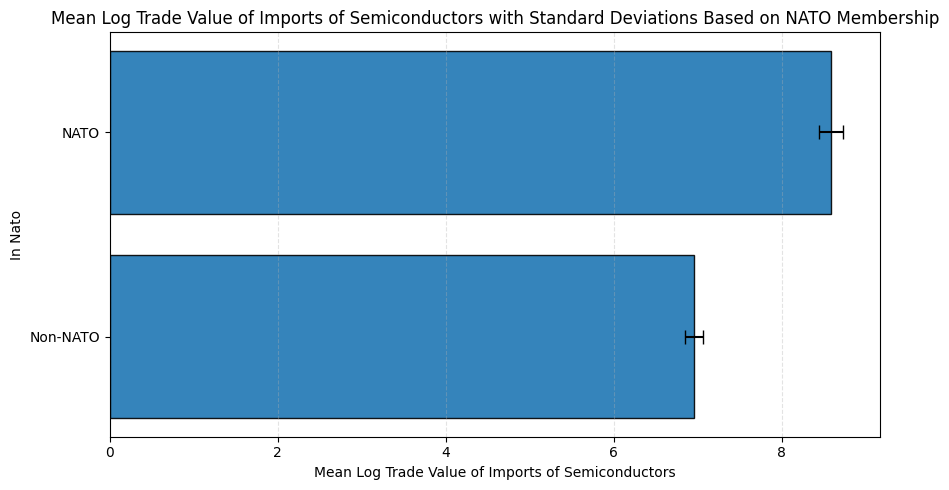

In [61]:
plot_data = boot_log_data[['In Nato', 'boot_mean', 'boot_se']].copy()
plot_data['boot_se'] = pd.to_numeric(plot_data['boot_se'])
plot_data = plot_data.sort_values('boot_mean')
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    y=plot_data['In Nato'],
    width=plot_data['boot_mean'],
    xerr=plot_data['boot_se'],
    edgecolor='black',
    alpha=0.9,
    capsize=5,
)
ax.set_xlabel('Mean Log Trade Value of Imports of Semiconductors')
ax.set_ylabel('In Nato')
ax.set_title('Mean Log Trade Value of Imports of Semiconductors with Standard Deviations Based on NATO Membership')
ax.grid(axis='x', linestyle='--', alpha=0.35)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Non-NATO', 'NATO'])
plt.tight_layout()
plt.show()

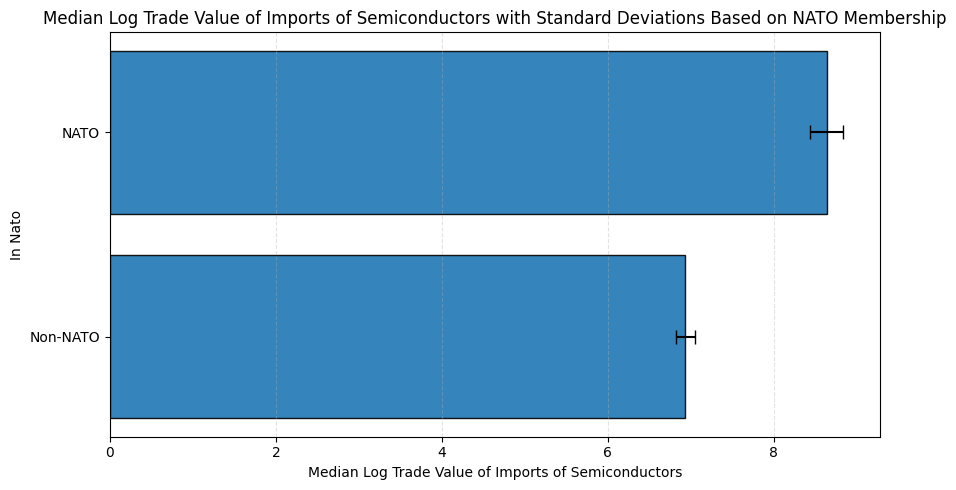

In [62]:
plot_data = boot_log_data[['In Nato', 'boot_median', 'boot_median_se']].copy()
plot_data['boot_se'] = pd.to_numeric(plot_data['boot_median_se'])
plot_data = plot_data.sort_values('boot_median')
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    y=plot_data['In Nato'],
    width=plot_data['boot_median'],
    xerr=plot_data['boot_median_se'],
    edgecolor='black',
    alpha=0.9,
    capsize=5,
)
ax.set_xlabel('Median Log Trade Value of Imports of Semiconductors')
ax.set_ylabel('In Nato')
ax.set_title('Median Log Trade Value of Imports of Semiconductors with Standard Deviations Based on NATO Membership')
ax.grid(axis='x', linestyle='--', alpha=0.35)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Non-NATO', 'NATO'])
plt.tight_layout()
plt.show()

In [63]:
boot_data['ci_lower'] = boot_data['boot_mean'] - 1.96 * boot_data['boot_se'].astype(float)
boot_data['ci_upper'] = boot_data['boot_mean'] + 1.96 * boot_data['boot_se'].astype(float)

boot_log_data['ci_lower'] = boot_log_data['boot_mean'] - 1.96 * boot_log_data['boot_se'].astype(float)
boot_log_data['ci_upper'] = boot_log_data['boot_mean'] + 1.96 * boot_log_data['boot_se'].astype(float)

print(boot_data[['In Nato', 'boot_mean', 'ci_lower', 'ci_upper']])
print(boot_log_data[['In Nato', 'boot_mean', 'ci_lower', 'ci_upper']])

   In Nato          boot_mean          ci_lower           ci_upper
0        0   435088194.940179  196857195.216236   673319194.664122
1        1  1627975410.586625  251883256.334999  3004067564.838251
   In Nato boot_mean  ci_lower  ci_upper
0        0  6.953292  6.748498  7.158085
1        1  8.589311  8.306134  8.872488


Above is the computed confidence intervals for raw and log trade values which can be interpreted as follows:

I am 95% confident that the mean import trade value of semiconductors for NATO countires is between $251,883,256.33 and $3,004,067,564.84.
I am 95% confident that the mean import trade value of semiconductors for Non-NATO countires is between $196,857,195.22 and $673,319,194.66.

I am 95% confident that the mean log import trade value of semiconductors for NATO countires is between 8.306134 and 8.872488.
I am 95% confident that the mean log import trade value of semiconductors for Non-NATO countires is between 6.748498 and 7.158085.

---
### Summary

Given our permutation tests and the resulting p-values we can comfortably reject the null hypothesis that any differences in trade value are only do to chance. The results of the bootstrap show that both the mean & median trade values are higher for NATO countries. These statements were true based on both the raw trade value scale and the log trade value scale. That being said it is to far of a stretch to say that NATO membership causes higher semiconductor imports. There are alot of other factors that should be considered if further inference was to be done. For example, which countries build the chips? What if Non-NATO countires are the primary builder/exporters so they don't rely on imports since they can produce them domestically. What impact does a countries GDP, Population, or Trade Agreements play on imports. These are all important questions, along with others not mentioned, that should be considered if a full analysis is to be done.